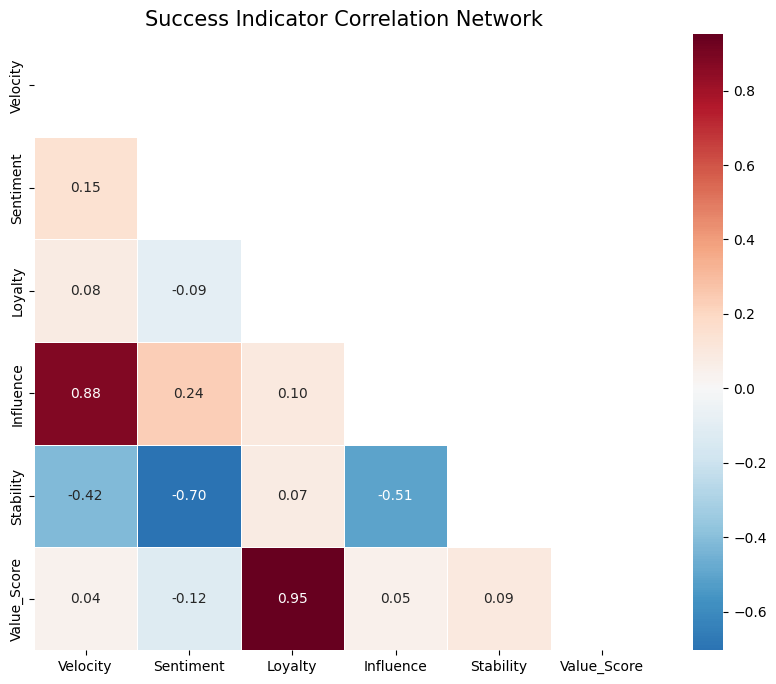


 분석 완료: 지표 간 상관관계 및 다중 공선성
    Feature       VIF
    Loyalty 10.914770
Value_Score 10.837506
  Influence  5.025037
   Velocity  4.531689
  Stability  2.647092
  Sentiment  2.105169


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. 데이터 로드 및 74개 정예 필터링
df_reviews = pd.read_csv('steam_indie_reviews.csv')
df_sample = pd.read_csv('steam_stratified_sample.csv')

df_reviews.columns = df_reviews.columns.str.strip()
df_sample.columns = df_sample.columns.str.strip()
df_reviews['appid'] = df_reviews['appid'].astype(str)
df_sample['appid'] = df_sample['appid'].astype(str)

# 74개 정예 게임 추출 (stratum 활용)
target_strata = ['large_high', 'mid_high', 'small_high']
df_high = df_sample[df_sample['stratum'].isin(target_strata)].copy()

# 2. 6대 지표(Feature Engineering) 생성
df_high['release_date_dt'] = pd.to_datetime(df_high['release_date'])
df_reviews['review_date'] = pd.to_datetime(df_reviews['timestamp_created'], unit='s')

# 가성비 계산을 위한 가격 복구 (없을 경우 0.01로 대체하여 에러 방지)
if 'price_spy' in df_high.columns:
    df_high['price_usd'] = df_high['price_spy'] * 100
df_high['price_usd'] = df_high['price_usd'].replace(0, 0.01)

# 초기 90일 데이터 병합
df_merged = pd.merge(df_reviews, df_high[['appid', 'release_date_dt', 'price_usd']], on='appid')
df_merged['days_since_release'] = (df_merged['review_date'] - df_merged['release_date_dt']).dt.days
df_m3 = df_merged[(df_merged['days_since_release'] >= 0) & (df_merged['days_since_release'] <= 90)].copy()

# 지표 집계
ml_df = df_m3.groupby('appid').agg(
    Velocity=('timestamp_created', 'count'),
    Sentiment=('voted_up', 'mean'),
    Loyalty=('author_playtime_at_review', 'mean'),
    Influence=('weighted_vote_score', 'sum')
).reset_index()

# Stability (안정도) 계산
daily_sent = df_m3.groupby(['appid', 'days_since_release'])['voted_up'].mean().reset_index()
stability = daily_sent.groupby('appid')['voted_up'].std().reset_index(name='Stability').fillna(0)
ml_df = pd.merge(ml_df, stability, on='appid')

# Value_Score (가성비) 계산
ml_df = pd.merge(ml_df, df_high[['appid', 'price_usd']], on='appid')
ml_df['Value_Score'] = ml_df['Loyalty'] / ml_df['price_usd']

# 분석에 사용할 지표만 선택
features = ['Velocity', 'Sentiment', 'Loyalty', 'Influence', 'Stability', 'Value_Score']
X = ml_df[features].dropna()

# 3. 상관관계 히트맵 시각화
plt.figure(figsize=(10, 8))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=.5)
plt.title('Success Indicator Correlation Network', fontsize=15)
plt.show()

# 4. 수동 VIF 계산
vif_dict = {}
for col in features:
    y_vif = X[col]
    X_vif = X.drop(columns=[col])
    lr = LinearRegression().fit(X_vif, y_vif)
    r_squared = lr.score(X_vif, y_vif)
    vif = 1 / (1 - r_squared) if r_squared < 1 else float('inf')
    vif_dict[col] = vif

vif_df = pd.DataFrame(list(vif_dict.items()), columns=['Feature', 'VIF']).sort_values(by='VIF', ascending=False)

print("\n" + "="*50)
print(" 분석 완료: 지표 간 상관관계 및 다중 공선성")
print("="*50)
print(vif_df.to_string(index=False))
print("="*50)